In [19]:
%load_ext autoreload
%autoreload 2

import time
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.tools.tools import add_constant

from pathlib import Path
import sys
_here = Path.cwd().resolve()
_root = next(p for p in [_here, *_here.parents] if (p / "src").is_dir())
sys.path.insert(0, str(_root / "src"))
from regression_modelling.constants import PREDICTOR_COLS, DEMOGRAPHIC_PREDICTORS, PROPERTY_PREDICTORS, TRANSIT_MODEL_PREDICTORS, IMAGERY_PREDICTORS, TARGET_CATEGORIES
from regression_modelling.data_wrangling.dataset import build_model_table

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [5]:
# Build the Chicago and Houston crime tables
sns.set_theme(style="whitegrid")
#start_time = time.time()
hou = build_model_table("houston", refresh=True)
chi = build_model_table("chicago",refresh=True)
kc = build_model_table("kansas_city",refresh=True)
#end_time = time.time()
#print(f"Time taken to build model tables: {end_time - start_time:.2f} seconds")
tables = {
    "houston": hou, 
    "chicago": chi,
    "kansas_city": kc}   # already built above

Houston city boundary loaded: 1 row(s)
Houston state block groups loaded: 18,626
Block groups within city: 1,629 / 18,626


/home/eprashar_solutions_corelogic_com/crime-idx-2026/src/crime_blockgroup_mapping/boundaries.py:30: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  bg['centroid'] = bg.geometry.centroid


Houston year_filter [2025-01-01, 2026-01-01): kept 240,696 of 240,696 rows (0 unparseable dates dropped)
Houston crime data: 237,011 rows with valid coords (of 240,696)
Matched to BG: 236,917 | Unmatched: 94
Mapped: 132,286 / 237,011 (55.8%)
Category counts:
crime_category
larceny     67789
vandal      20426
assault     13041
mvt         12355
burglary    11284
robbery      4973
rape         1921
murder        289
fire          208

Unmapped: 104,725 records across 38 codes
BG-level category aggregation: 2,079 BGs (1,600 within city, 479 outside)
Crime Totals:
assault_count      13032.0
murder_count         288.0
rape_count          1921.0
robbery_count       4971.0
burglary_count     11284.0
larceny_count      67775.0
mvt_count          12349.0
vandal_count       20421.0
violent_count      20212.0
property_count     91408.0
cl_total_count    111620.0
dtype: float64
Analysis set: 2,108 BGs
  Inside city:  1,629 (1,600 with data, 29 without)
  Outside city: 479 (all with crime data)
Mod

/home/eprashar_solutions_corelogic_com/crime-idx-2026/src/crime_blockgroup_mapping/boundaries.py:30: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  bg['centroid'] = bg.geometry.centroid
/home/eprashar_solutions_corelogic_com/crime-idx-2026/src/crime_blockgroup_mapping/crime.py:50: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  dt = pd.to_datetime(df[cfg.date_col], errors='coerce')


Chicago year_filter [2025-01-01, 2026-01-01): kept 237,207 of 237,207 rows (0 unparseable dates dropped)
Chicago crime data: 235,767 rows with valid coords (of 237,207)
Matched to BG: 235,690 | Unmatched: 77
Mapped: 129,757 / 235,767 (55.0%)
Category counts:
crime_category
larceny     58322
vandal      26091
mvt         17164
assault     13640
burglary     6167
robbery      5780
rape         1792
murder        431
fire          370

Unmapped: 106,010 records across 15 codes
BG-level category aggregation: 2,256 BGs (2,164 within city, 92 outside)
Crime Totals:
assault_count      13636.0
murder_count         429.0
rape_count          1792.0
robbery_count       5775.0
burglary_count      6167.0
larceny_count      58295.0
mvt_count          17163.0
vandal_count       26081.0
violent_count      21632.0
property_count     81625.0
cl_total_count    103257.0
dtype: float64
Analysis set: 2,256 BGs
  Inside city:  2,164 (2,164 with data, 0 without)
  Outside city: 92 (all with crime data)
Model 

/home/eprashar_solutions_corelogic_com/crime-idx-2026/src/crime_blockgroup_mapping/boundaries.py:30: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  bg['centroid'] = bg.geometry.centroid


Block groups within city: 473 / 5,031
Kansas City year_filter [2025-01-01, 2026-01-01): kept 97,557 of 99,085 rows (1 unparseable dates dropped)
Kansas City dedup on ('report_no', 'ibrs'): kept 55,168 of 97,557 rows
Kansas City crime data: 53,469 rows with valid coords (of 55,168)
Matched to BG: 53,266 | Unmatched: 203
Mapped: 28,853 / 53,469 (54.0%)
Category counts:
crime_category
larceny     10115
mvt          5814
vandal       5184
assault      3519
burglary     2576
robbery      1007
rape          452
murder        117
fire           69

Unmapped: 18,657 records across 34 codes
BG-level category aggregation: 660 BGs (473 within city, 187 outside)
Crime Totals:
assault_count      3504.0
murder_count        117.0
rape_count          449.0
robbery_count      1004.0
burglary_count     2572.0
larceny_count     10091.0
mvt_count          5796.0
vandal_count       5179.0
violent_count      5074.0
property_count    18459.0
cl_total_count    23533.0
dtype: float64
Analysis set: 660 BGs
  In

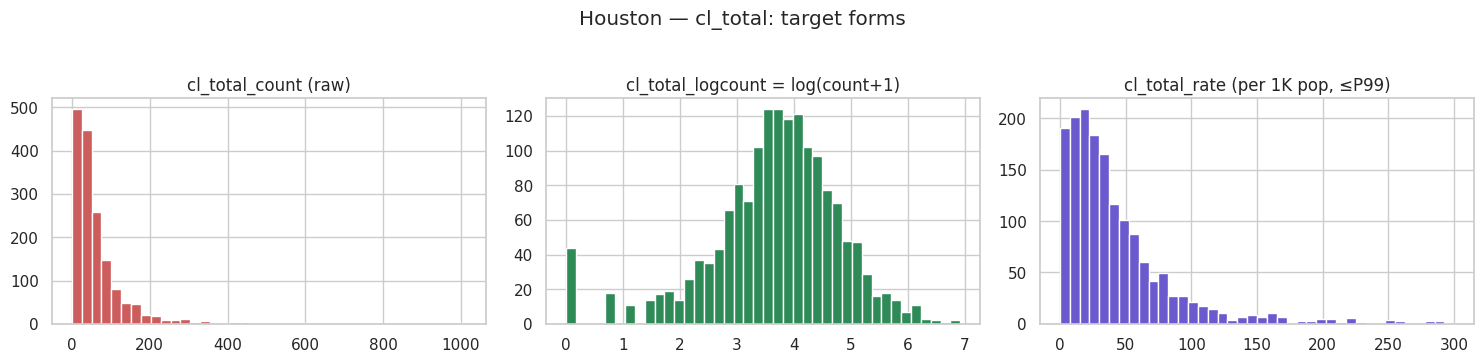

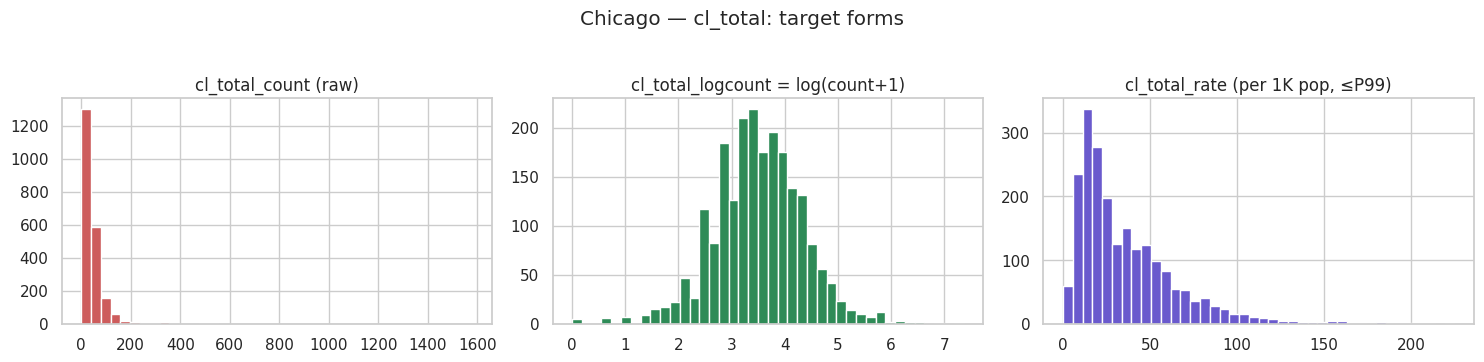

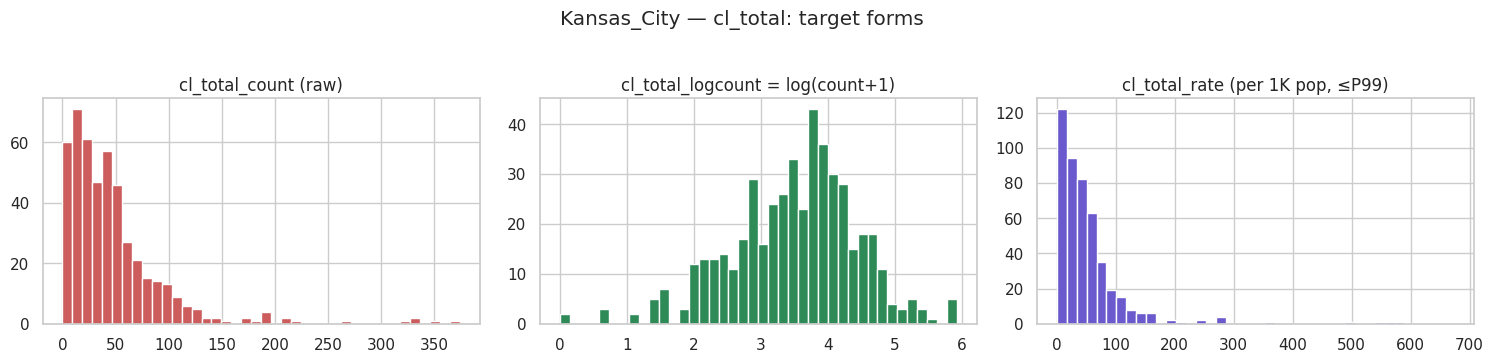

In [ ]:
# Confirms log(count+1) tames the skew that raw counts show
def plot_target_forms(df, cat, city, rate_clip_pct=99):
    fig, axes = plt.subplots(1, 3, figsize=(15, 3.5))
    axes[0].hist(df[f"{cat}_count"], bins=40, color="indianred", edgecolor="white")
    axes[0].set_title(f"{cat}_count (raw)")
    axes[1].hist(df[f"{cat}_logcount"], bins=40, color="seagreen", edgecolor="white")
    axes[1].set_title(f"{cat}_logcount = log(count+1)")

    rate = df[f"{cat}_rate"].dropna()
    rate_range = (0, rate.quantile(rate_clip_pct / 100)) if rate_clip_pct else None
    axes[2].hist(rate, bins=40, range=rate_range, color="slateblue", edgecolor="white")
    axes[2].set_title(f"{cat}_rate (per 1K pop, ≤P{rate_clip_pct})")

    fig.suptitle(f"{city} — {cat}: target forms", y=1.03); fig.tight_layout(); plt.show()

for city, df in tables.items():
    plot_target_forms(df, "cl_total", city.title())

### Checking predictor families one by one using:
1. Basic Descriptive Statistics
2. Distributions
3. Correlations among independent variables in the family
4. Correlation of independant variable with _crime_rates

In [ ]:
# --- family-EDA helpers (defined once; each family section below reuses them) ---
# imagery is currently included in PREDICTOR_COLS for convenience; families let us read
# each block on its own before the combined view at the end.
FAMILIES = {
    "demographic": DEMOGRAPHIC_PREDICTORS,
    "property":    PROPERTY_PREDICTORS,
    "transit":     TRANSIT_MODEL_PREDICTORS,
    "imagery":     IMAGERY_PREDICTORS,
}

def describe_cols(df, cols):
    d = df[cols].describe(percentiles=[.01, .05, .25, .5, .75, .95, .99]).T
    d["skew"] = df[cols].skew()
    d["n_missing"] = df[cols].isna().sum()
    d["pct_missing"] = (df[cols].isna().mean() * 100).round(1)
    return d.round(2)

def plot_grid(df, cols, title, bins=40, color="steelblue"):
    ncol = 3
    nrow = int(np.ceil(len(cols) / ncol))
    fig, axes = plt.subplots(nrow, ncol, figsize=(5 * ncol, 3.2 * nrow))
    axes = np.atleast_1d(axes).ravel()
    for ax, c in zip(axes, cols):
        ax.hist(df[c].dropna(), bins=bins, color=color, edgecolor="white")
        ax.set_title(c); ax.set_ylabel("BGs")
    for ax in axes[len(cols):]:
        ax.set_visible(False)
    fig.suptitle(title, fontsize=13, y=1.02); fig.tight_layout(); plt.show()

def corr_heatmap(df, cols, title, annot=True, figsize=None):
    corr = df[cols].corr(method="spearman")
    figsize = figsize or (max(6, 1.1 * len(cols)), max(5, 1.0 * len(cols)))
    fig, ax = plt.subplots(figsize=figsize)
    sns.heatmap(corr, annot=annot, fmt=".2f", cmap="RdYlGn", center=0,
                vmin=-1, vmax=1, square=True, cbar_kws={"shrink": .8}, ax=ax)
    ax.set_title(title); plt.tight_layout(); plt.show()

def vif_table(df, cols):
    X = add_constant(df[cols].apply(pd.to_numeric, errors="coerce").fillna(df[cols].median()))
    vif = pd.DataFrame({"feature": X.columns,
                        "VIF": [variance_inflation_factor(X.values, i) for i in range(X.shape[1])]})
    return vif[vif["feature"] != "const"].sort_values("VIF", ascending=False).round(2)

def family_target_corr(df, cols, targets, suffix):
    """Spearman of each predictor in `cols` vs each `{target}_{suffix}` column.
    suffix='rate' is the primary target (ADR 0003); 'logcount' is the comparator."""
    tcols = [f"{t}_{suffix}" for t in targets if f"{t}_{suffix}" in df.columns]
    have  = [c for c in cols if c in df.columns]
    corr = df[have + tcols].corr(method="spearman").loc[have, tcols]
    corr.columns = [t for t in targets if f"{t}_{suffix}" in df.columns]
    return corr.round(2)

### Demographic family

In [ ]:
# 1. descriptive stats — demographic
for city, df in tables.items():
    print(f"\n{'='*60}\n{city.upper()} — demographic summary\n{'='*60}")
    display(describe_cols(df, DEMOGRAPHIC_PREDICTORS))

In [ ]:
# 2. distributions — demographic
for city, df in tables.items():
    plot_grid(df, DEMOGRAPHIC_PREDICTORS, f"{city.title()} — demographic distributions")

In [ ]:
# 3. intra-family correlations (Spearman) — demographic
for city, df in tables.items():
    corr_heatmap(df, DEMOGRAPHIC_PREDICTORS, f"{city.title()} — demographic correlations")

In [ ]:
# 4. correlation with crime rates (primary target, ADR 0003) — demographic
for city, df in tables.items():
    print(f"\n{city.upper()} — demographic vs crime rate (Spearman)")
    display(family_target_corr(df, DEMOGRAPHIC_PREDICTORS, TARGET_CATEGORIES, "rate"))

### Property family

In [ ]:
# 1. descriptive stats — property
for city, df in tables.items():
    print(f"\n{'='*60}\n{city.upper()} — property summary\n{'='*60}")
    display(describe_cols(df, PROPERTY_PREDICTORS))

In [ ]:
# 2. distributions — property
for city, df in tables.items():
    plot_grid(df, PROPERTY_PREDICTORS, f"{city.title()} — property distributions")

In [ ]:
# 3. intra-family correlations (Spearman) — property
for city, df in tables.items():
    corr_heatmap(df, PROPERTY_PREDICTORS, f"{city.title()} — property correlations")

In [ ]:
# 4. correlation with crime rates (primary target, ADR 0003) — property
for city, df in tables.items():
    print(f"\n{city.upper()} — property vs crime rate (Spearman)")
    display(family_target_corr(df, PROPERTY_PREDICTORS, TARGET_CATEGORIES, "rate"))

### Transit (model form) family

In [ ]:
# 1. descriptive stats — transit
for city, df in tables.items():
    print(f"\n{'='*60}\n{city.upper()} — transit summary\n{'='*60}")
    display(describe_cols(df, TRANSIT_MODEL_PREDICTORS))

In [ ]:
# 2. distributions — transit
for city, df in tables.items():
    plot_grid(df, TRANSIT_MODEL_PREDICTORS, f"{city.title()} — transit distributions")

In [ ]:
# 3. intra-family correlations (Spearman) — transit
for city, df in tables.items():
    corr_heatmap(df, TRANSIT_MODEL_PREDICTORS, f"{city.title()} — transit correlations")

In [ ]:
# 4. correlation with crime rates (primary target, ADR 0003) — transit
for city, df in tables.items():
    print(f"\n{city.upper()} — transit vs crime rate (Spearman)")
    display(family_target_corr(df, TRANSIT_MODEL_PREDICTORS, TARGET_CATEGORIES, "rate"))

### Imagery (Vexcel — candidates) family

In [ ]:
# 1. descriptive stats — imagery
for city, df in tables.items():
    print(f"\n{'='*60}\n{city.upper()} — imagery summary\n{'='*60}")
    display(describe_cols(df, IMAGERY_PREDICTORS))

In [ ]:
# 2. distributions — imagery
for city, df in tables.items():
    plot_grid(df, IMAGERY_PREDICTORS, f"{city.title()} — imagery distributions")

In [ ]:
# 3. intra-family correlations (Spearman) — imagery
for city, df in tables.items():
    corr_heatmap(df, IMAGERY_PREDICTORS, f"{city.title()} — imagery correlations")

In [ ]:
# 4. correlation with crime rates (primary target, ADR 0003) — imagery
for city, df in tables.items():
    print(f"\n{city.upper()} — imagery vs crime rate (Spearman)")
    display(family_target_corr(df, IMAGERY_PREDICTORS, TARGET_CATEGORIES, "rate"))

### Combined — all families together

Once each family reads cleanly on its own, the full picture: cross-family collinearity, VIF on the whole fit-set, and every predictor vs the targets. Diagnostics only — no auto-prune (ADR 0003).

In [ ]:
# combined intra-predictor correlation (all families) — annot off, it's a big matrix
for city, df in tables.items():
    corr_heatmap(df, PREDICTOR_COLS, f"{city.title()} — all predictors (Spearman)",
                 annot=False, figsize=(16, 14))

In [ ]:
# combined VIF over the full fit-set
for city, df in tables.items():
    print(f"\n{city.upper()} — VIF (all predictors)")
    display(vif_table(df, PREDICTOR_COLS))

In [ ]:
# combined predictor vs targets — rate (primary) and log-count (comparator)
for suffix in ("rate", "logcount"):
    for city, df in tables.items():
        print(f"\n{city.upper()} — all predictors vs target (Spearman, {suffix})")
        display(family_target_corr(df, PREDICTOR_COLS, TARGET_CATEGORIES, suffix))